# An illustrated guide to automatic sparse differentiation

> Reference: [An Illustrated Guide to Automatic Sparse Differentiation](https://iclr-blogposts.github.io/2025/blog/sparse-autodiff/#ad-is-matrix-free)
>
> Last updated: 12 Aug 2026

## Automatic differentiation (AD)

The jacobian operator $Df:\boldsymbol{x} \mapsto Df(\boldsymbol{x})$ is a linear map which provides the best linear approximation of a function $f$ at a point $\boldsymbol{x}$. The jacobian matrices are the representation of Jacobian operators in the standard basis.

The computational cost of one JVP/VJP of $f$ is approximately the same as the cost of one evaluation of $f$.

Materialization means that a composition of Jacobian operators is turned into a dense Jacobian matrix.

## Automatic sparse differentiation (ASD)

Two columns or rows of the Jacobian matrix are **structurally orthogonal** if, for every index, at most one of them has a nonzero coefficient, which means the dot product is always zero.

The core idea of ASD is that **we can materialize multiple structurally orthogonal columns (or rows) with a single JVP (or VJP)**, which was first suggested in 1974 by Curtis, Powell and Reid.
$$
Df(\boldsymbol{x})(\boldsymbol{\boldsymbol{e}_i+\cdots+\boldsymbol{e}_j}) = Df(\boldsymbol{x})(\boldsymbol{e}_i) + \cdots + Df(\boldsymbol{x})(\boldsymbol{e}_j)
$$
where each component on the right-hand side corresponds to a column of the Jacobian matrix. If these columns are structurally orthogonal, the sum can be uniquely decomposed into its components, a process called **decomposition**. 

To detect the sparse pattern, we can use a **coloring algorithm** to group orthogonal columns (or rows) together.

To sum up, ASD consists of four steps:

1. Pattern detection
2. Coloring
3. Compressed AD
4. Decompression

This compression-based pipeline is described at length by Gebremedhin, Manne and Pothen in their landmark survey, or in Chapter 8 of the book by Griewank and Walther. An alternative, direct pipeline is presented in Chapter 7 of the same book.

The first two steps are much slower than a single evaluation of $f$, but they are usually much faster than evaluating the full Jacobian matrix via AD. Meanwhile, the cost of this prelude can be amortized over multiple evaluations of $f$ at different points.

## Pattern detection

The index set tells us which inputs influence a given output (for forward mode).

The goal is to propagate the index set such that we get an output vector of index sets that corresponds to the Jacobian sparse pattern.

Another important concept is the **abstract interpretation**, which means we imbue the computational graph with a different meaning.

We consider two abstract interpretations: 

* **Global sparisty detection** 

    Instead of computing values, each primitive operation computes accumulate the index sets of its inputs and propagate them to the outputs.

    The resulting index sets are valid over the entire input domain.


* **Local sparsity detection**

    The original primal computation is propagated alongside the index sets. The resulting index sets are valid only for the given input point.

    The resulting local sparsity pattern is a strict subset of the global sparsity pattern, and can therefore result in fewer colors. However, they need to be recomputed when changing the input.

## Coloring

Once we have detected the sparse pattern, we can use a **coloring algorithm** to group orthogonal columns (or rows) together. 

Let us build a graph $\mathcal{G}=(\mathcal{V},\mathcal{E})$ with vertex set $\mathcal{V}$ denoting the columns (or rows) of the Jacobian matrix. Two vertices are connected only if they are not structurally orthogonal and should be assigned different colors $c$.

Greedy algorithms are often used to color the graph $\mathcal{G}$, which assigns to each vertex the smallest color that is not used by its neighbors and never backtracks. A crucial hyperparameter is the choice of ordering of the vertices.

Bicoloring allows combining forward and reverse modes.

## Second order

The key subroutine of second-order AD is the Hessian-vector product (HVP) 

$$
\nabla^2 f(\boldsymbol{x})\cdot\boldsymbol{v} = D[\nabla f](\boldsymbol{x})(\boldsymbol{v})
$$

which is computed in a forward-over-reverse manner and scales roughly with the complexity of $f$. The forward-over-forward is also possible and less expensive in terms of storage but has a higher complexity.

The symmetry of the Hessian matrix makes the pattern detection and coloring steps require special care. 

## Implementations

### Problem setup

In [111]:
import os

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/asdex-numba-cache")

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import asdex

from jax_fem.problem import Problem
from jax_fem.generate_mesh import (
    get_meshio_cell_type,
    Mesh,
    rectangle_mesh,
)


In [112]:
# Linear elastic material
E = 70e3
nu = 0.3

mu = E / (2.0 * (1.0 + nu))
lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))


class LinearElasticity(Problem):
    def get_tensor_map(self):
        def stress(u_grad):
            epsilon = 0.5 * (u_grad + u_grad.T)
            sigma = (
                lmbda * jnp.trace(epsilon) * jnp.eye(self.dim)
                + 2.0 * mu * epsilon
            )
            return sigma

        return stress


In [113]:
# A structured QUAD4 mesh on the unit square
ele_type = "QUAD4"
cell_type = get_meshio_cell_type(ele_type)

Nx = 10
Ny = 10

meshio_mesh = rectangle_mesh(
    Nx=Nx,
    Ny=Ny,
    domain_x=1.0,
    domain_y=1.0,
)

mesh = Mesh(
    meshio_mesh.points,
    meshio_mesh.cells_dict[cell_type],
)

print("Mesh points:", mesh.points.shape)
print("Mesh cells: ", mesh.cells.shape)


Mesh points: (121, 2)
Mesh cells:  (100, 4)


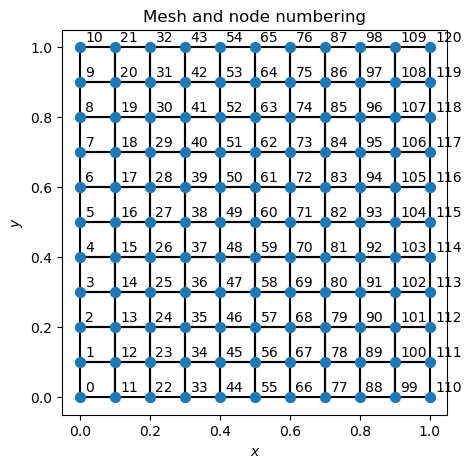

In [114]:
# Visualize the mesh and node numbering
points = np.asarray(mesh.points)
cells = np.asarray(mesh.cells)

fig, ax = plt.subplots(figsize=(5, 5))
for cell in cells:
    polygon = points[np.r_[cell, cell[0]]]
    ax.plot(*polygon.T, "k-")

ax.scatter(*points.T, s=50, color="tab:blue", zorder=3)
for node_id, (x, y) in enumerate(points):
    ax.annotate(node_id, (x, y), xytext=(4, 4), textcoords="offset points")

ax.set(aspect="equal", xlabel=r"$x$", ylabel=r"$y$", title="Mesh and node numbering")
plt.show()


In [115]:
# No Dirichlet or Neumann boundary conditions are imposed.
problem = LinearElasticity(
    mesh=mesh,
    vec=2,
    dim=2,
    ele_type=ele_type,
    dirichlet_bc_info=None,
)

fe = problem.fes[0]
num_nodes = fe.num_total_nodes
num_dofs = fe.num_total_dofs

print(f"Number of nodes: {num_nodes}")
print(f"Number of dofs:  {num_dofs}")
print(f"Number of cells: {fe.num_cells}")
print("shape_grads:", fe.shape_grads.shape)
print("JxW:        ", fe.JxW.shape)


[08-12 21:17:33][INFO] jax_fem: Computing shape function values, gradients, etc.
[08-12 21:17:33][INFO] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[08-12 21:17:33][INFO] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[08-12 21:17:33][INFO] jax_fem: Solving a problem with 100 cells, 121x2 = 242 dofs.
[08-12 21:17:33][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.
[08-12 21:17:33][INFO] jax_fem: Pre-computations took 0.002 [s]


Number of nodes: 121
Number of dofs:  242
Number of cells: 100
shape_grads: (100, 4, 4, 2)
JxW:         (100, 4)


In [116]:
# Pure JAX residual map R: R^ndof -> R^ndof
def residual_flat(u_flat):
    u = u_flat.reshape(num_nodes, 2)
    residual = problem.compute_residual([u])[0]
    return residual.reshape(-1)


u0 = jnp.zeros(num_dofs)
r0 = residual_flat(u0)

print("Displacement shape:", u0.shape)
print("Residual shape:    ", r0.shape)
print("Residual norm:     ", float(jnp.linalg.norm(r0)))


[08-12 21:17:33][DEBUG] jax_fem: Computing cell residual...


Displacement shape: (242,)
Residual shape:     (242,)
Residual norm:      0.0


In [117]:
# Dense reference tangent stiffness matrix K = dR/du
K_dense = jax.jacfwd(residual_flat)(u0)

symmetry_error = (
    jnp.linalg.norm(K_dense - K_dense.T)
    / jnp.linalg.norm(K_dense)
)

print("Stiffness shape:        ", K_dense.shape)
print("Relative symmetry error:", float(symmetry_error))


[08-12 21:17:33][DEBUG] jax_fem: Computing cell residual...


Stiffness shape:         (242, 242)
Relative symmetry error: 5.89141831549325e-17


### Sparsity pattern detection

In [118]:
# Conservative sparsity pattern implied by finite-element connectivity
topological_pattern = np.zeros(
    (num_dofs, num_dofs),
    dtype=bool,
)

topological_pattern[problem.I, problem.J] = True

print("Topological nonzeros:", np.count_nonzero(topological_pattern))


Topological nonzeros: 3844


In [119]:
# Global sparsity pattern detected from the JAX computation graph
detected_pattern = asdex.jacobian_sparsity(
    residual_flat,
    u0,
)

asd_pattern = np.zeros(
    detected_pattern.shape,
    dtype=bool,
)

asd_pattern[
    detected_pattern.rows,
    detected_pattern.cols,
] = True

print(detected_pattern)


[08-12 21:17:33][DEBUG] jax_fem: Computing cell residual...


SparsityPattern(242×242, nnz=3844, sparsity=93.4%)
⎡⠻⣦⡀⠘⢷⣆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⣀⠈⠻⣦⡀⠙⢷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠹⢷⣄⠈⠻⣦⡀⠙⢷⣤⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢷⣄⠈⠻⣦⡀⠙⠿⣤⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⣷⣄⠈⠻⣦⡀⠙⢿⣤⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠛⣧⣄⠈⠛⣤⡀⠙⢻⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠛⣷⣄⠈⠻⣦⡀⠙⢷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠛⢶⣄⠈⠻⣦⡀⠙⢷⣄⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢷⣄⠈⠻⣦⡀⠙⢷⣆⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢷⣄⠈⠻⣦⡀⠙⢷⣆⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠹⢷⣄⠈⠻⣦⡀⠙⢷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠹⢷⣄⠈⠻⣦⡀⠙⢷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠙⢷⣄⠈⠻⣦⡀⠙⠷⣤⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢷⣄⠈⠻⣦⡀⠙⢿⣤⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⣧⣄⠈⠛⣤⡀⠙⢻⣤⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠛⣷⣄⠈⠻⣦⡀⠙⢿⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠛⣶⣄⠈⠻⣦⡀⠙⢷⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠛⢷⣄⠈⠻⣦⡀⠙⢷⣆⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢷⣄⠈⠻⣦⡀⠉⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠹⢷⡄⠈⠻⣦⎦


FE topology: nnz = 3844
ASD global detection: nnz = 3844
Numerical reference: nnz = 2963
Numerical pattern covered by ASD: True
ASD pattern covered by topology:  True


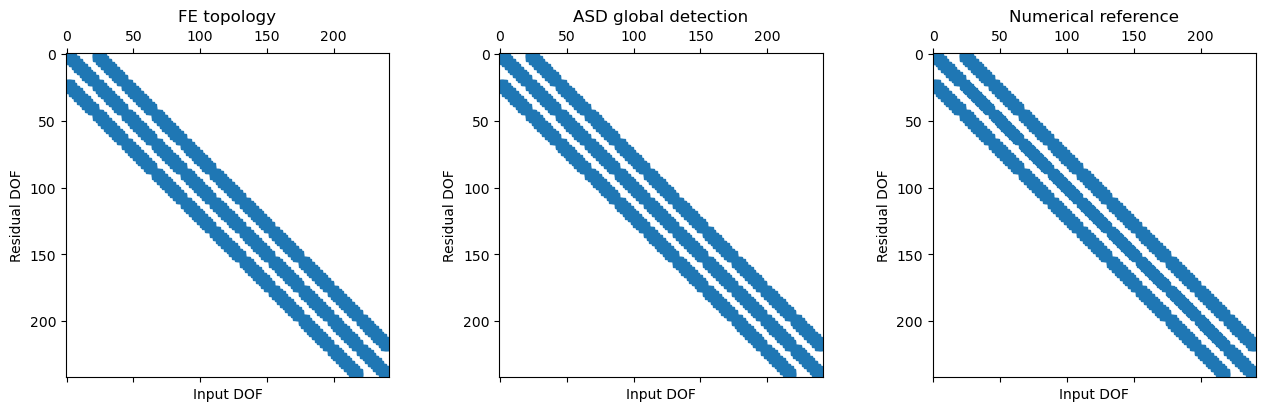

In [120]:
# Compare and visualize the three sparsity patterns
numerical_pattern = np.abs(np.asarray(K_dense)) > 1e-10

patterns = [
    ("FE topology", topological_pattern),
    ("ASD global detection", asd_pattern),
    ("Numerical reference", numerical_pattern),
]

for name, pattern in patterns:
    print(f"{name}: nnz = {np.count_nonzero(pattern)}")

print("Numerical pattern covered by ASD:", np.all(~numerical_pattern | asd_pattern))
print("ASD pattern covered by topology: ", np.all(~asd_pattern | topological_pattern))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, (title, pattern) in zip(axes, patterns):
    ax.spy(pattern, markersize=4)
    ax.set(title=title, xlabel="Input DOF", ylabel="Residual DOF")

plt.show()


### Graph coloring

In [121]:
# Compare ordinary column coloring with symmetric coloring
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", asdex.DenseColoringWarning)
    column_coloring = asdex.jacobian_coloring_from_sparsity(
        detected_pattern,
        mode="fwd",
    )
    symmetric_coloring = asdex.jacobian_coloring_from_sparsity(
        detected_pattern,
        mode="fwd",
        symmetric=True,
    )

print(f"Uncompressed columns: {num_dofs}")
print(f"Column coloring:       {column_coloring.num_colors} colors")
print(f"Symmetric coloring:    {symmetric_coloring.num_colors} colors")


Uncompressed columns: 242
Column coloring:       18 colors
Symmetric coloring:    20 colors


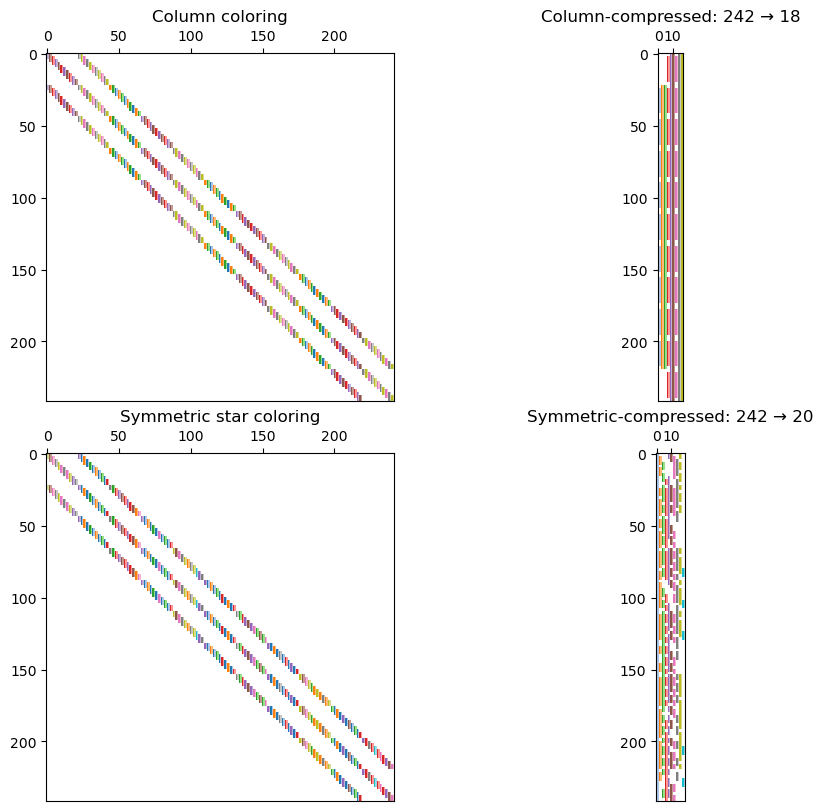

In [122]:
# Colored patterns and their compressed representations
cmap = "tab20"

fig, axes = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)

asdex.spy(column_coloring, ax=axes[0, 0], cmap=cmap)
asdex.spy(column_coloring, compressed=True, ax=axes[0, 1], cmap=cmap)
asdex.spy(symmetric_coloring, ax=axes[1, 0], cmap=cmap)
asdex.spy(symmetric_coloring, compressed=True, ax=axes[1, 1], cmap=cmap)

axes[0, 0].set_title("Column coloring")
axes[0, 1].set_title(f"Column-compressed: {num_dofs} → {column_coloring.num_colors}")
axes[1, 0].set_title("Symmetric star coloring")
axes[1, 1].set_title(f"Symmetric-compressed: {num_dofs} → {symmetric_coloring.num_colors}")

plt.show()


### Compressed differentiation and decompression

In [123]:
# One seed vector and one JVP for each column color
colors = jnp.asarray(column_coloring.colors)
num_colors = column_coloring.num_colors

seed_matrix = jax.nn.one_hot(
    colors,
    num_colors,
    dtype=u0.dtype,
)

compressed_jacobian = jax.vmap(
    lambda seed: jax.jvp(residual_flat, (u0,), (seed,))[1]
)(seed_matrix.T).T

print("Seed matrix shape:         ", seed_matrix.shape)
print("Compressed Jacobian shape:", compressed_jacobian.shape)
print(f"JVP seed directions: {num_dofs} → {num_colors}")


[08-12 21:17:33][DEBUG] jax_fem: Computing cell residual...


Seed matrix shape:          (242, 18)
Compressed Jacobian shape: (242, 18)
JVP seed directions: 242 → 18


In [124]:
# Recover every structural nonzero from its color column
rows = jnp.asarray(detected_pattern.rows)
cols = jnp.asarray(detected_pattern.cols)

K_decompressed = jnp.zeros_like(K_dense).at[rows, cols].set(
    compressed_jacobian[rows, colors[cols]]
)

K_asdex = asdex.jacobian_from_coloring(
    residual_flat,
    column_coloring,
    output_format="dense",
)(u0)

manual_error = jnp.linalg.norm(K_decompressed - K_dense) / jnp.linalg.norm(K_dense)
asdex_error = jnp.linalg.norm(K_asdex - K_dense) / jnp.linalg.norm(K_dense)

print("Manual decompression error:", float(manual_error))
print("asdex reconstruction error:", float(asdex_error))


[08-12 21:17:33][DEBUG] jax_fem: Computing cell residual...


Manual decompression error: 4.74564539186454e-17
asdex reconstruction error: 0.0


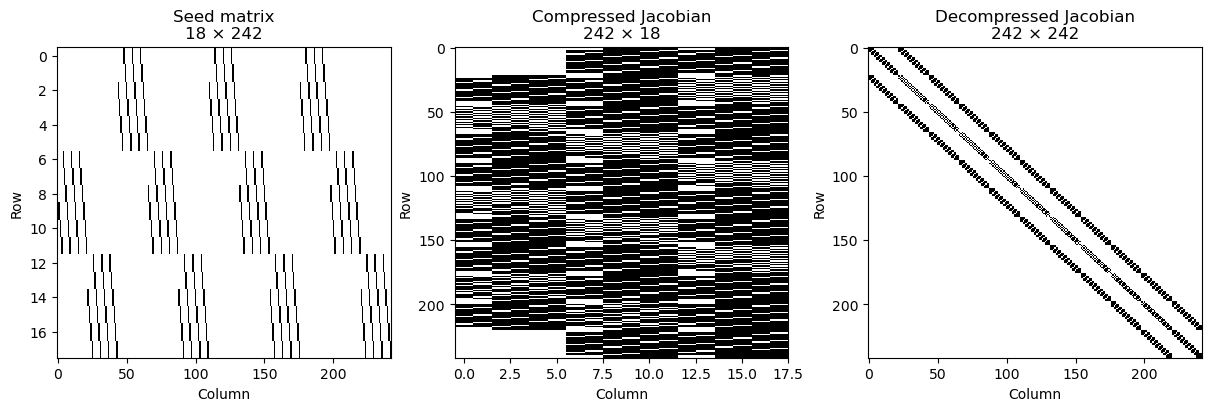

In [125]:
# Seed, compressed, and decompressed sparsity patterns
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

images = [
    (seed_matrix.T, "Seed matrix"),
    (jnp.abs(compressed_jacobian) > 1e-10, "Compressed Jacobian"),
    (jnp.abs(K_decompressed) > 1e-10, "Decompressed Jacobian"),
]

for ax, (image, title) in zip(axes, images):
    ax.imshow(image, cmap="Greys", interpolation="none", aspect="auto")
    ax.set_title(f"{title}\n{image.shape[0]} × {image.shape[1]}")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

plt.show()


### Timing comparison

In [126]:
# jax.jacfwd internally vmaps JVPs over the standard basis
# All methods return the same dense Jacobian for a fair comparison
dense_jacobian_fn = jax.jit(jax.jacfwd(residual_flat))

@jax.jit
def manual_asd_fn(u):
    compressed = jax.vmap(
        lambda seed: jax.jvp(residual_flat, (u,), (seed,))[1]
    )(seed_matrix.T).T

    return jnp.zeros((num_dofs, num_dofs), dtype=u.dtype).at[rows, cols].set(
        compressed[rows, colors[cols]]
    )

asdex_jacobian_fn = jax.jit(
    asdex.jacobian_from_coloring(
        residual_flat,
        column_coloring,
        output_format="dense",
    )
)

methods = {
    "Dense JAX": dense_jacobian_fn,
    "Manual ASD": manual_asd_fn,
    "asdex": asdex_jacobian_fn,
}


[08-12 21:17:33][DEBUG] jax_fem: Computing cell residual...
[08-12 21:17:34][DEBUG] jax_fem: Computing cell residual...
[08-12 21:17:34][DEBUG] jax_fem: Computing cell residual...


Dense JAX  | first call:  179.28 ms | median: 1663.67 µs | speedup:  1.00x | relative error: 0.0e+00
Manual ASD | first call:  125.76 ms | median:  411.29 µs | speedup:  4.04x | relative error: 4.7e-17
asdex      | first call:  127.55 ms | median:  400.58 µs | speedup:  4.15x | relative error: 4.7e-17


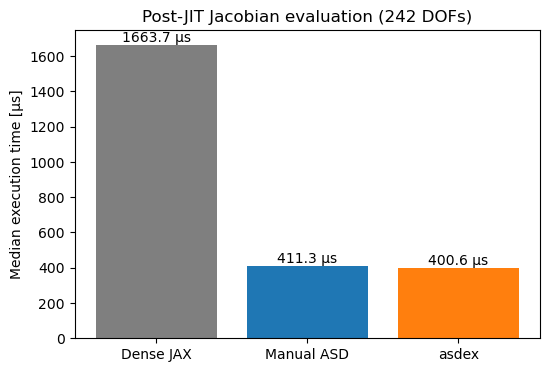

In [127]:
# First call includes JIT compilation; repeated calls measure execution time only
import time

repeats = 100
timing_results = {}
reference_norm = jnp.linalg.norm(K_dense)

for name, fn in methods.items():
    start = time.perf_counter()
    result = fn(u0)
    result.block_until_ready()
    first_call_ms = 1e3 * (time.perf_counter() - start)

    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        fn(u0).block_until_ready()
        samples.append(1e6 * (time.perf_counter() - start))

    timing_results[name] = {
        "first_call_ms": first_call_ms,
        "median_us": float(np.median(samples)),
        "relative_error": float(jnp.linalg.norm(result - K_dense) / reference_norm),
    }

baseline = timing_results["Dense JAX"]["median_us"]
for name, result in timing_results.items():
    speedup = baseline / result["median_us"]
    print(
        f"{name:10s} | first call: {result['first_call_ms']:7.2f} ms "
        f"| median: {result['median_us']:7.2f} µs "
        f"| speedup: {speedup:5.2f}x "
        f"| relative error: {result['relative_error']:.1e}"
    )

names = list(timing_results)
times = [timing_results[name]["median_us"] for name in names]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(names, times, color=["tab:gray", "tab:blue", "tab:orange"])
ax.bar_label(bars, fmt="%.1f µs")
ax.set_ylabel("Median execution time [µs]")
ax.set_title(f"Post-JIT Jacobian evaluation ({num_dofs} DOFs)")
plt.show()
